In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import os

# Create results directory in the notebook directory
os.makedirs("results", exist_ok=True)
print("Results directory created at:", os.path.abspath("results"))

Results directory created at: c:\Users\la7tim\Desktop\Internship\FedTinyProp\notebooks\results


In [4]:
import torchvision
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

# Print dataset info
print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")
print(f"Number of classes: {len(trainset.classes)}")

Training set size: 50000
Test set size: 10000
Number of classes: 100


In [5]:
num_clients = 5
partitions = {
    "dirichlet_iid":      dirichlet_partition(trainset, num_clients=num_clients, alpha=1000.0),  # High alpha -> IID-like
    "dirichlet_noniid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),   # Low alpha -> non-IID
    "dirichlet_medium":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.5),   # Medium skew
}


=== Partition Statistics for CIFAR-100 ===

DIRICHLET_IID Partition:
Total samples: 50000

Per-client distribution:
Client 0: 9932 samples (19.86%)
Client 1: 10011 samples (20.02%)
Client 2: 9975 samples (19.95%)
Client 3: 9996 samples (19.99%)
Client 4: 10086 samples (20.17%)

DIRICHLET_NONIID Partition:
Total samples: 50000

Per-client distribution:
Client 0: 8400 samples (16.80%)
Client 1: 9175 samples (18.35%)
Client 2: 10850 samples (21.70%)
Client 3: 9548 samples (19.10%)
Client 4: 12027 samples (24.05%)

DIRICHLET_MEDIUM Partition:
Total samples: 50000

Per-client distribution:
Client 0: 9077 samples (18.15%)
Client 1: 10927 samples (21.85%)
Client 2: 9472 samples (18.94%)
Client 3: 11900 samples (23.80%)
Client 4: 8624 samples (17.25%)
[Debug] Number of classes: 100
[Debug] Number of clients: 5
[Debug] Processing client 0 with 9932 samples
[Debug] Client 0 has 9932 valid targets
[Debug] Client 0 class counts: [ 98.  99. 102.  98. 102. 100.  94. 103.  99.  97. 100.  99.  96.  9

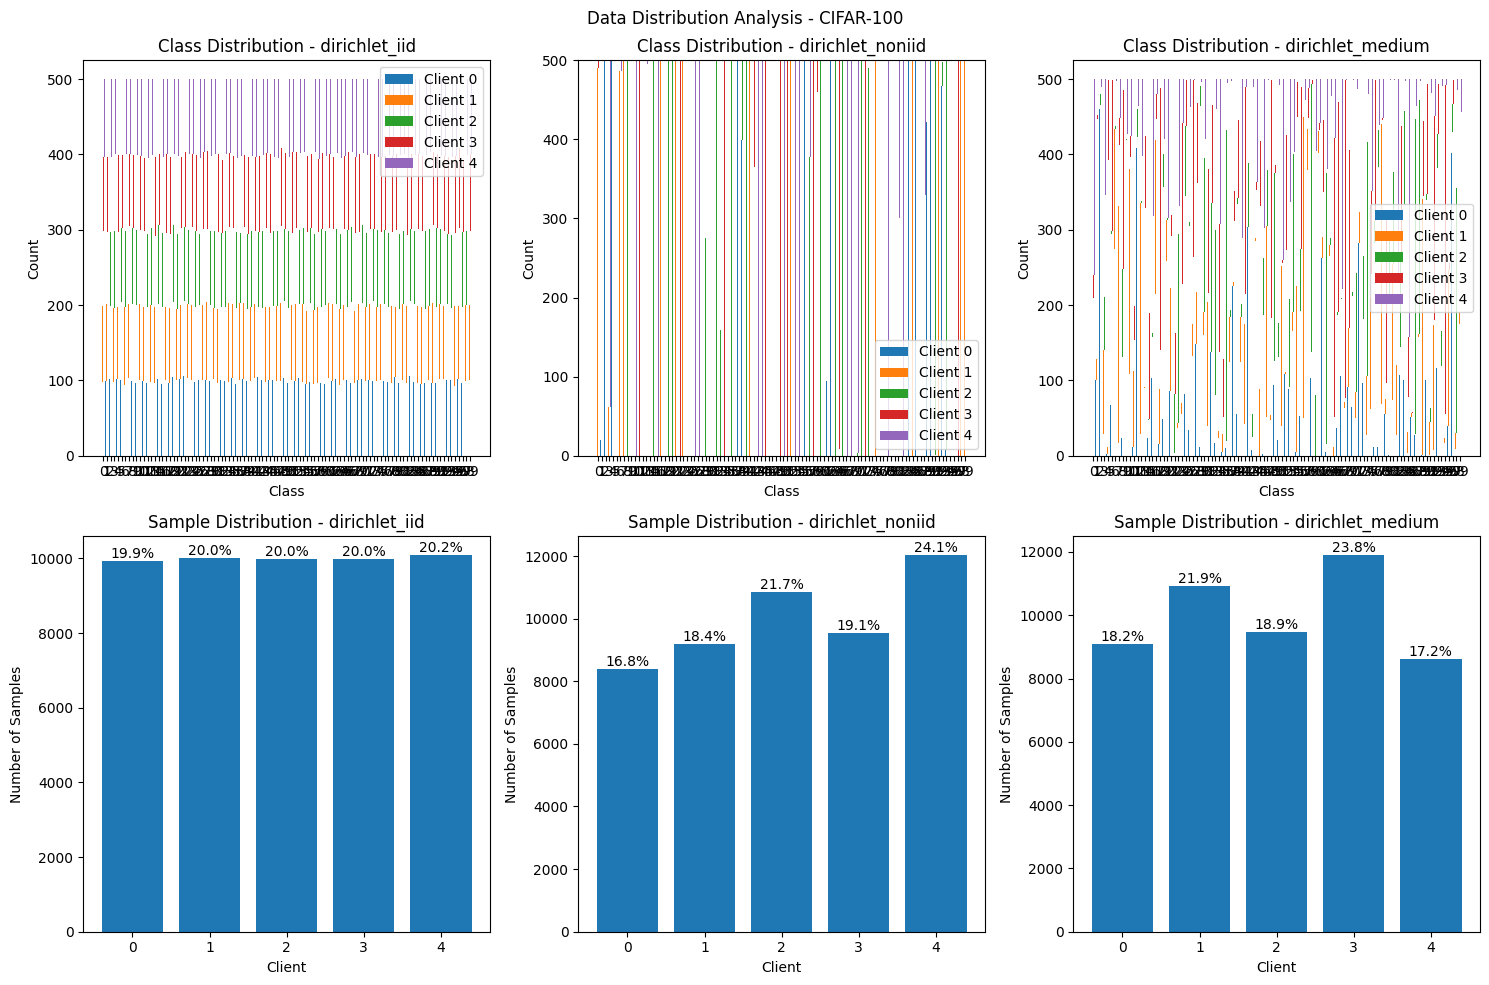

In [6]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "CIFAR-100")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "CIFAR-100")
plt.show()

In [7]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("cifar100")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x00000183EB6E94D0>
skip_threshold: 2.5
full_flops_per_batch: 1000000.0
phi_min: 0.2
optimizer: {'type': 'sgd', 'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}
lr_scheduler: {'type': 'cosine', 'T_max': 100, 'eta_min': 0.0001, 'warmup_epochs': 5, 'warmup_start_lr': 0.001}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
data_augmentation: {'random_crop': True, 'random_horizontal_flip': True, 'random_rotation': 5, 'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2}}
quantization: {'bits': 8, 'enabled': True}

TinyProp Parameters:
S_min: 0.05
S_max: 0.5
zeta: 0.25
number_of_layers: 8


In [ ]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    quantization_errors, avg_scale_factors, history = federated_training(
        client_datasets=client_datasets,
        model_name='cifar100',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=100,
        early_stopping_delta=0.001,
        csv_log_path=f'results/cifaaaar100_{partition_name}_training_log.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        quantization_bits=8,  # Add quantization bits parameter
        save_dir='results',  # Add save directory for logs
        save_interval=1  # Save metrics every round
    )
    
    # Store quantization metrics in history
    history['quantization_errors'] = quantization_errors
    history['avg_scale_factors'] = avg_scale_factors
    
    return model, history

# Update the config to include quantization parameters
config = get_tinyprop_config('cifar100')
config['quantization_bits'] = 8  # Add quantization bits to config

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history,
            'quantization_metrics': {
                'errors': history['quantization_errors'],
                'scale_factors': history['avg_scale_factors']
            }
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue




Starting training for DIRICHLET_IID partition...

Training on partition: DIRICHLET_IID

Round 1/100
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Batch 5] Debug Info:
  - Loss: 4.6331
  - Loss Change: 0.0000
  - Relative Loss Change: 0.0000
  - Dynamic Threshold: 0.2000
  - Current phi_k: 0.4552
  - Current phi_max: 0.9900
  - Layer Sparsity: 0.1138
  - Skip Ratio: 0.2000
  - Current Skip Ratio: 0.2000
  - Should Skip: False
[Debug][Batch 5] Loss: 4.6692
[Debug][Batch 5] Loss Change: 0.0361
[Debug][Batch 5] Relative Loss Change: 0.0078
[Debug][Batch 5] Phi Update: -0.0008
[Debug][Batch 5] New phi_k: 0.4545
[Debug] phi_k_history: [0.37897220228569883, 0.378048040148684, 0.45614871880900315, 0.45516986273853327, 0.4545469524556661]

[B

Found IID results at results/cifaaaar100_dirichlet_iid_training_log.csv
Found NON-IID results at results/cifaaaar100_dirichlet_noniid_training_log.csv
Found MEDIUM results at results/cifaaaar100_dirichlet_medium_training_log.csv


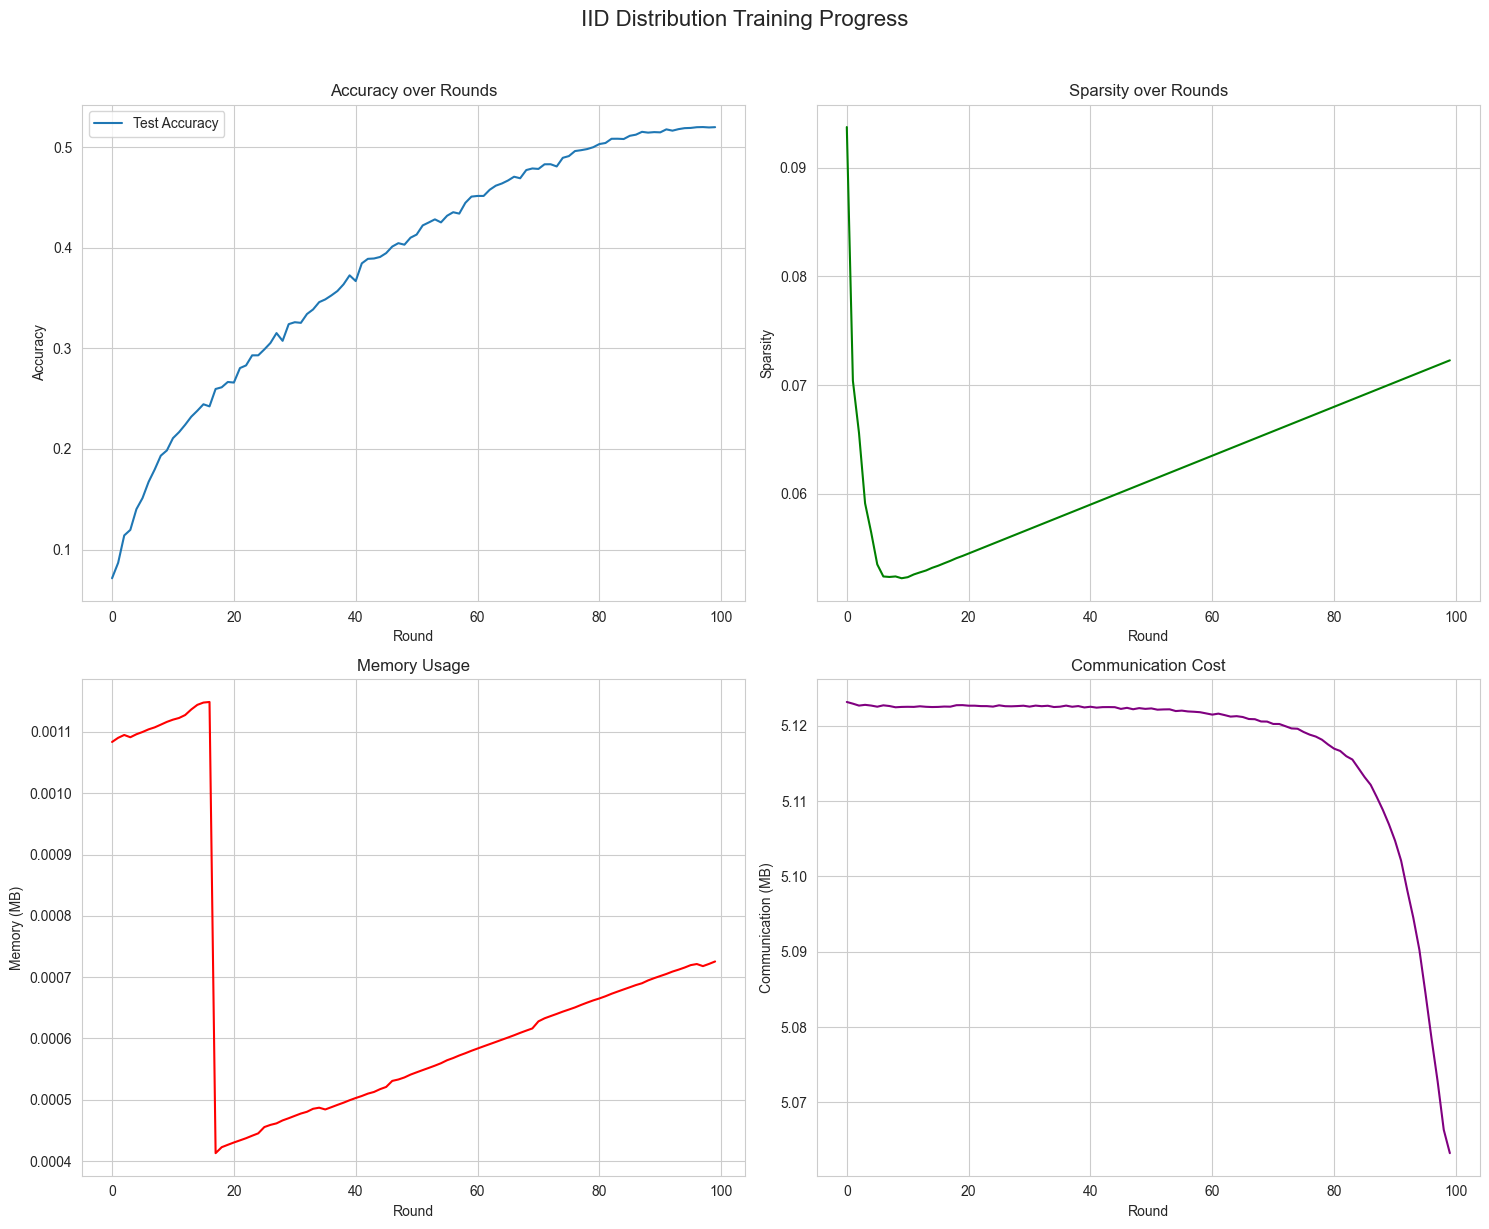

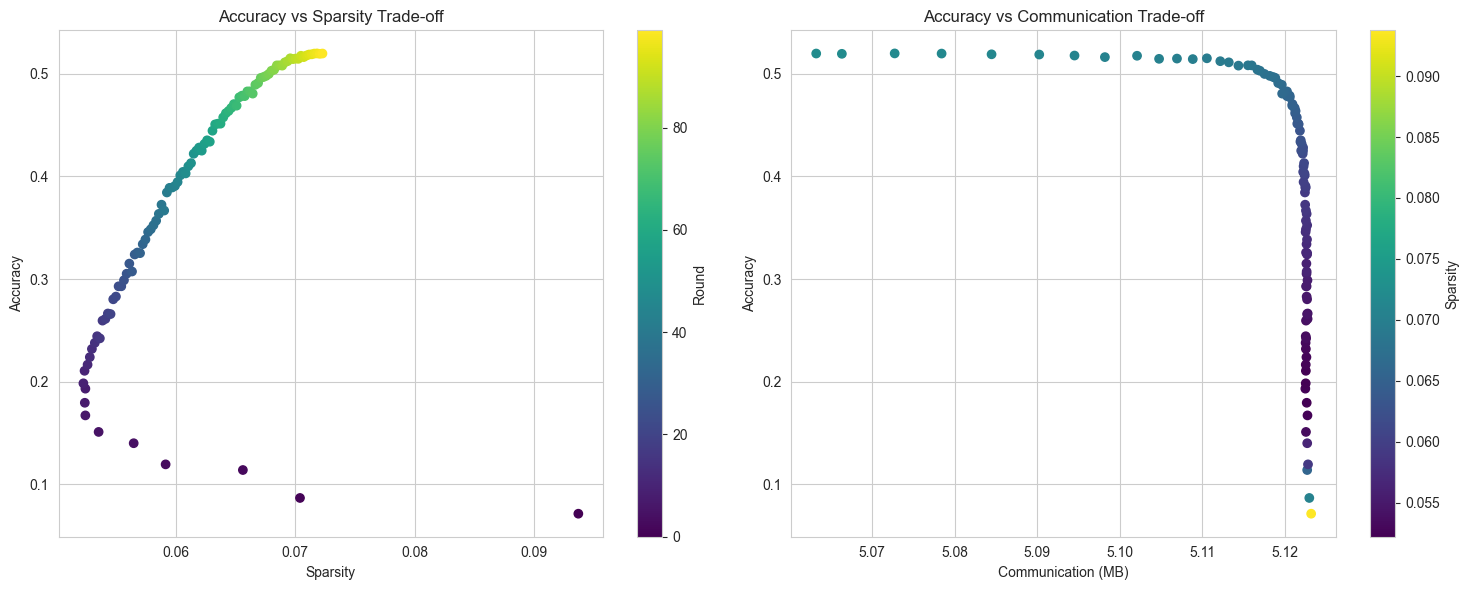

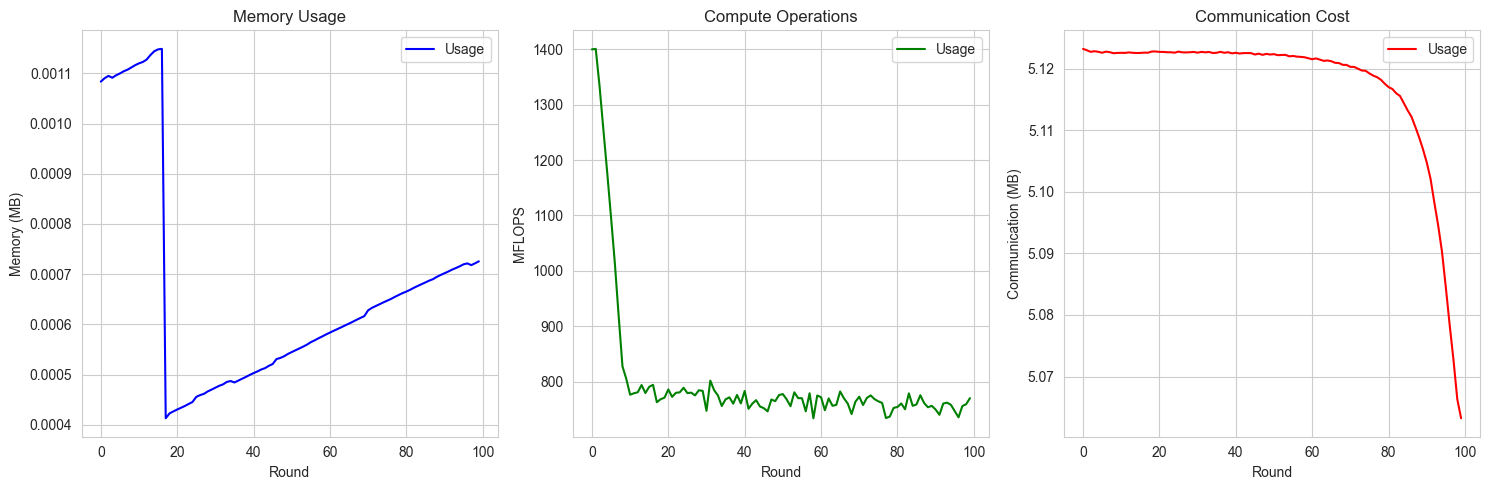

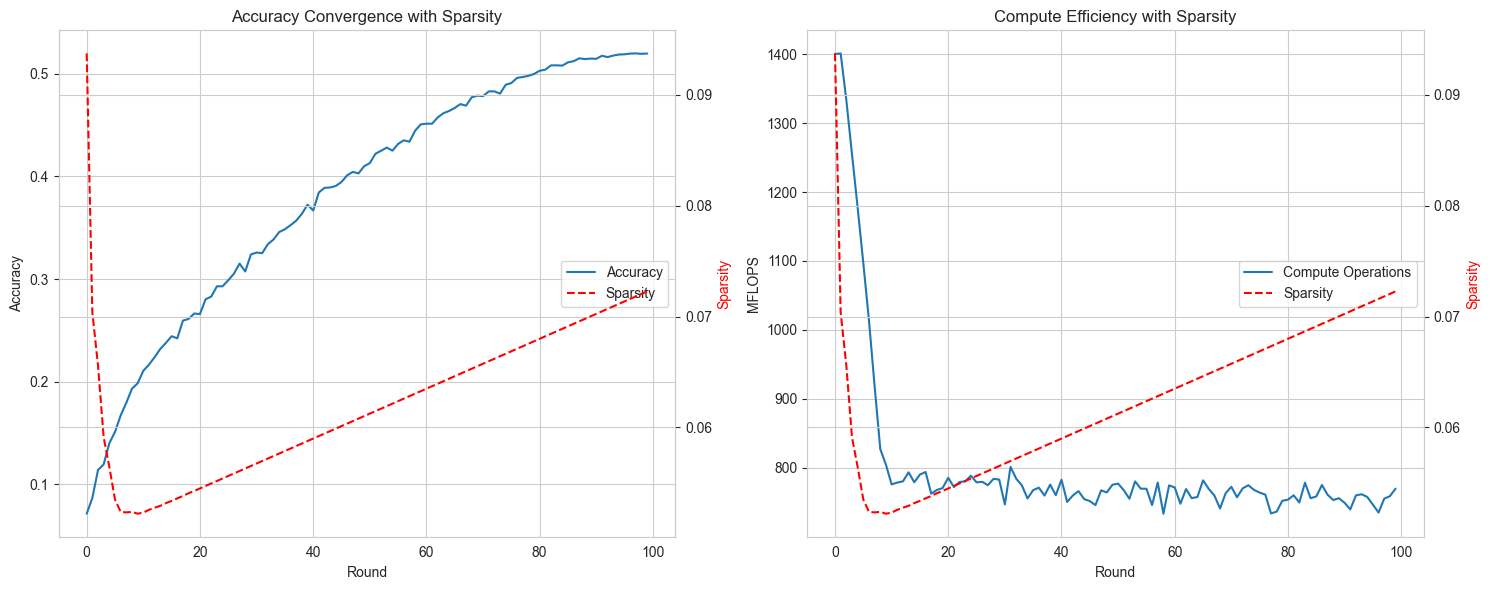

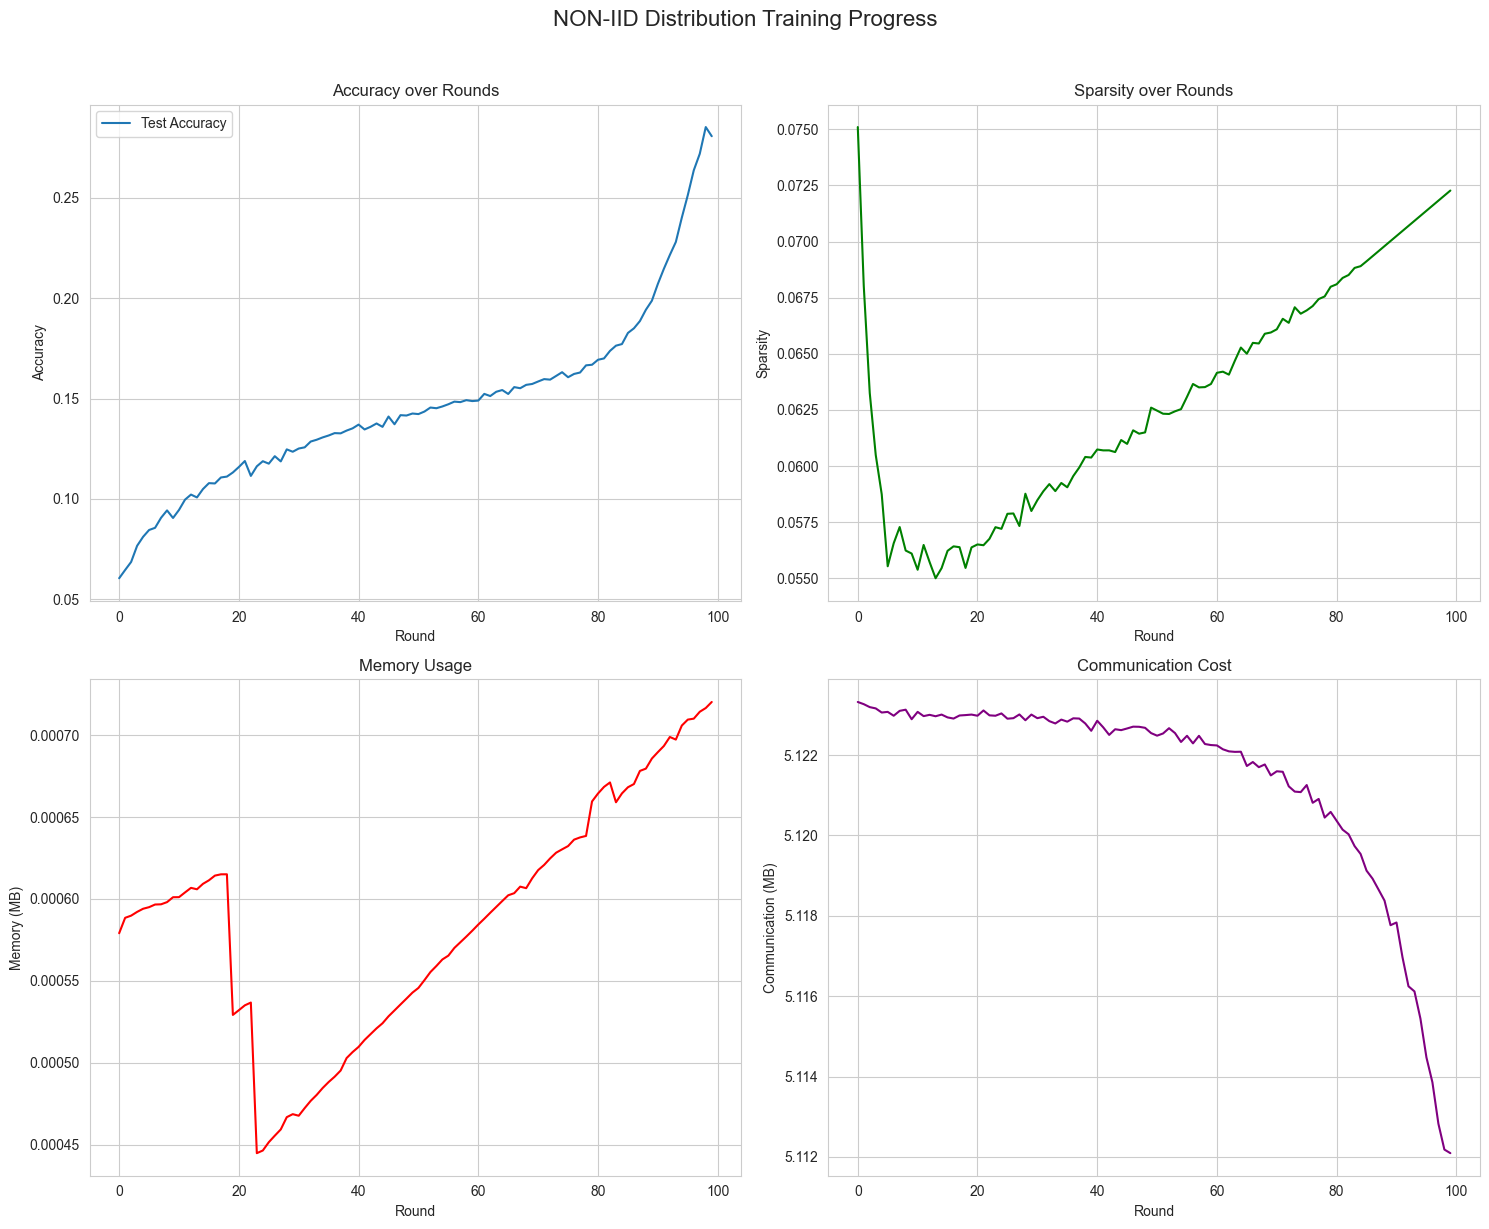

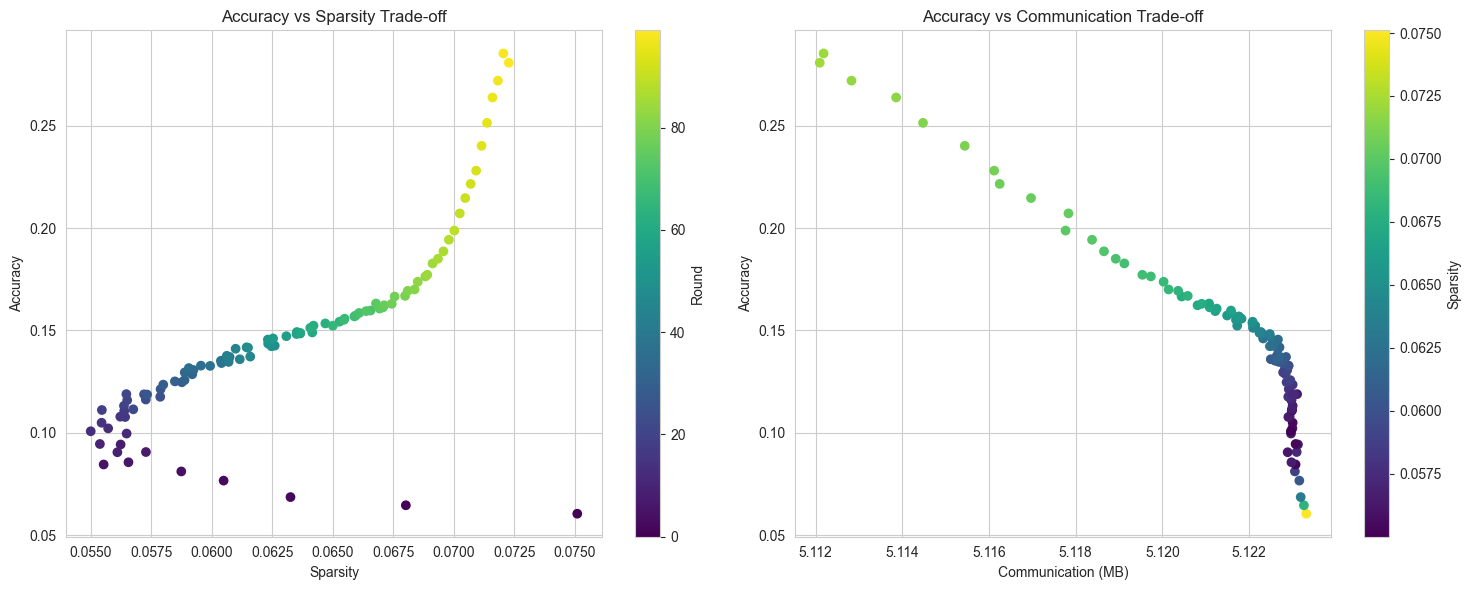

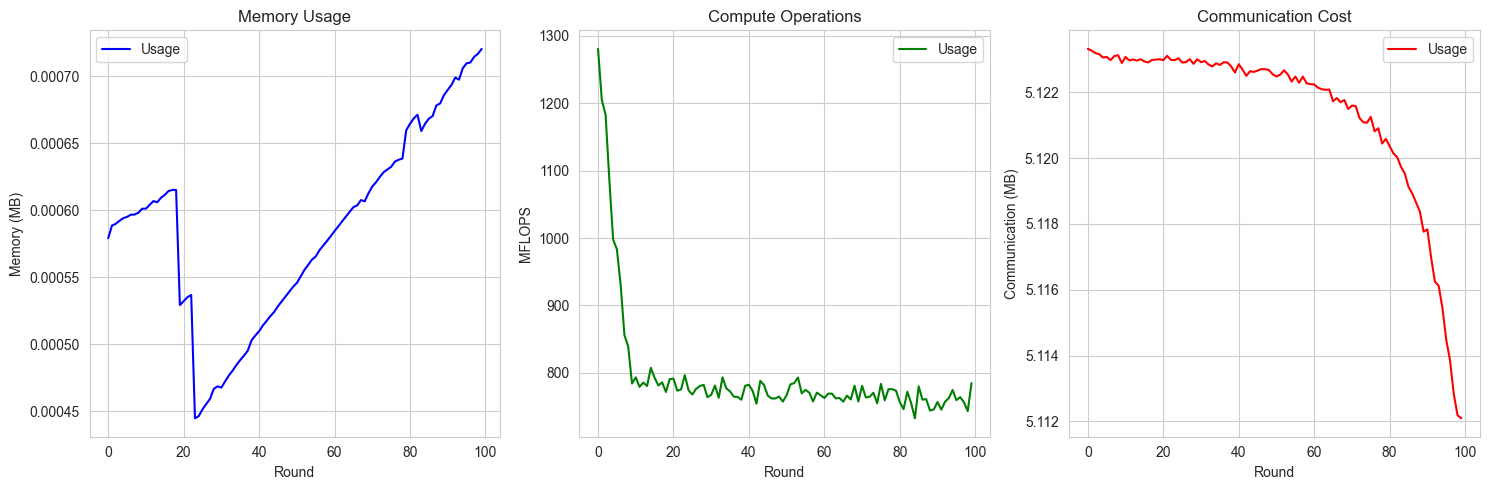

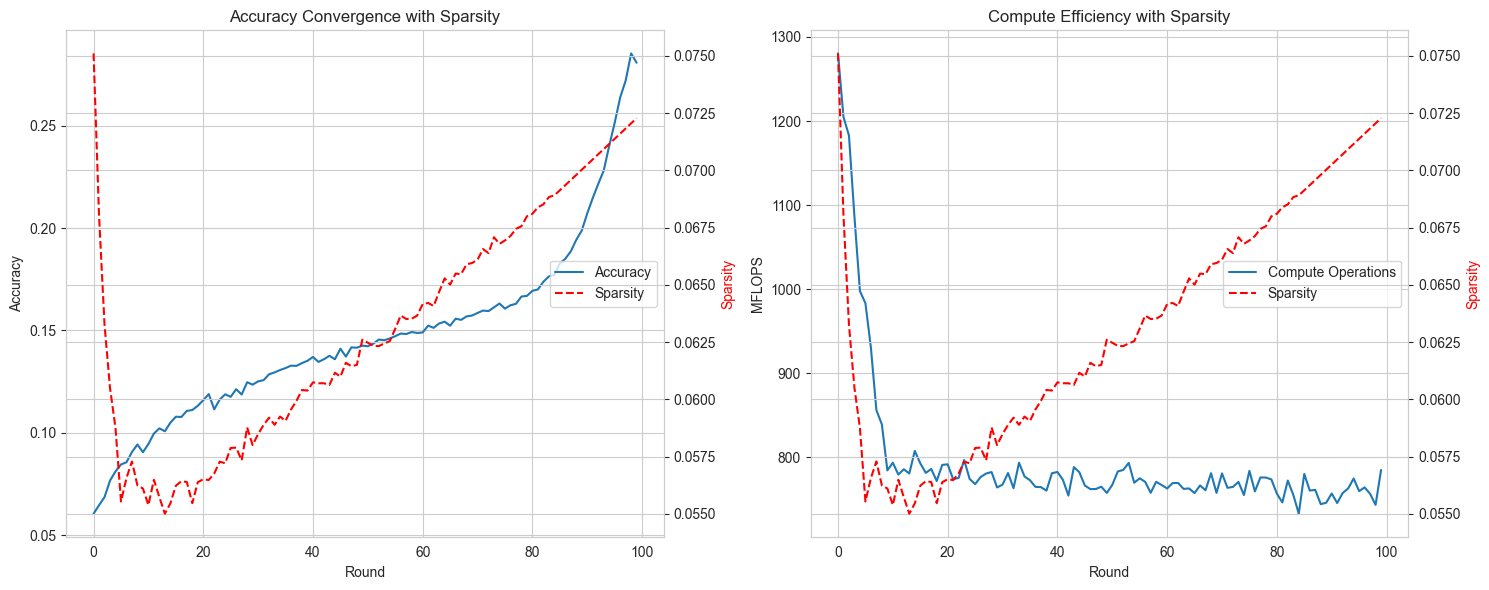

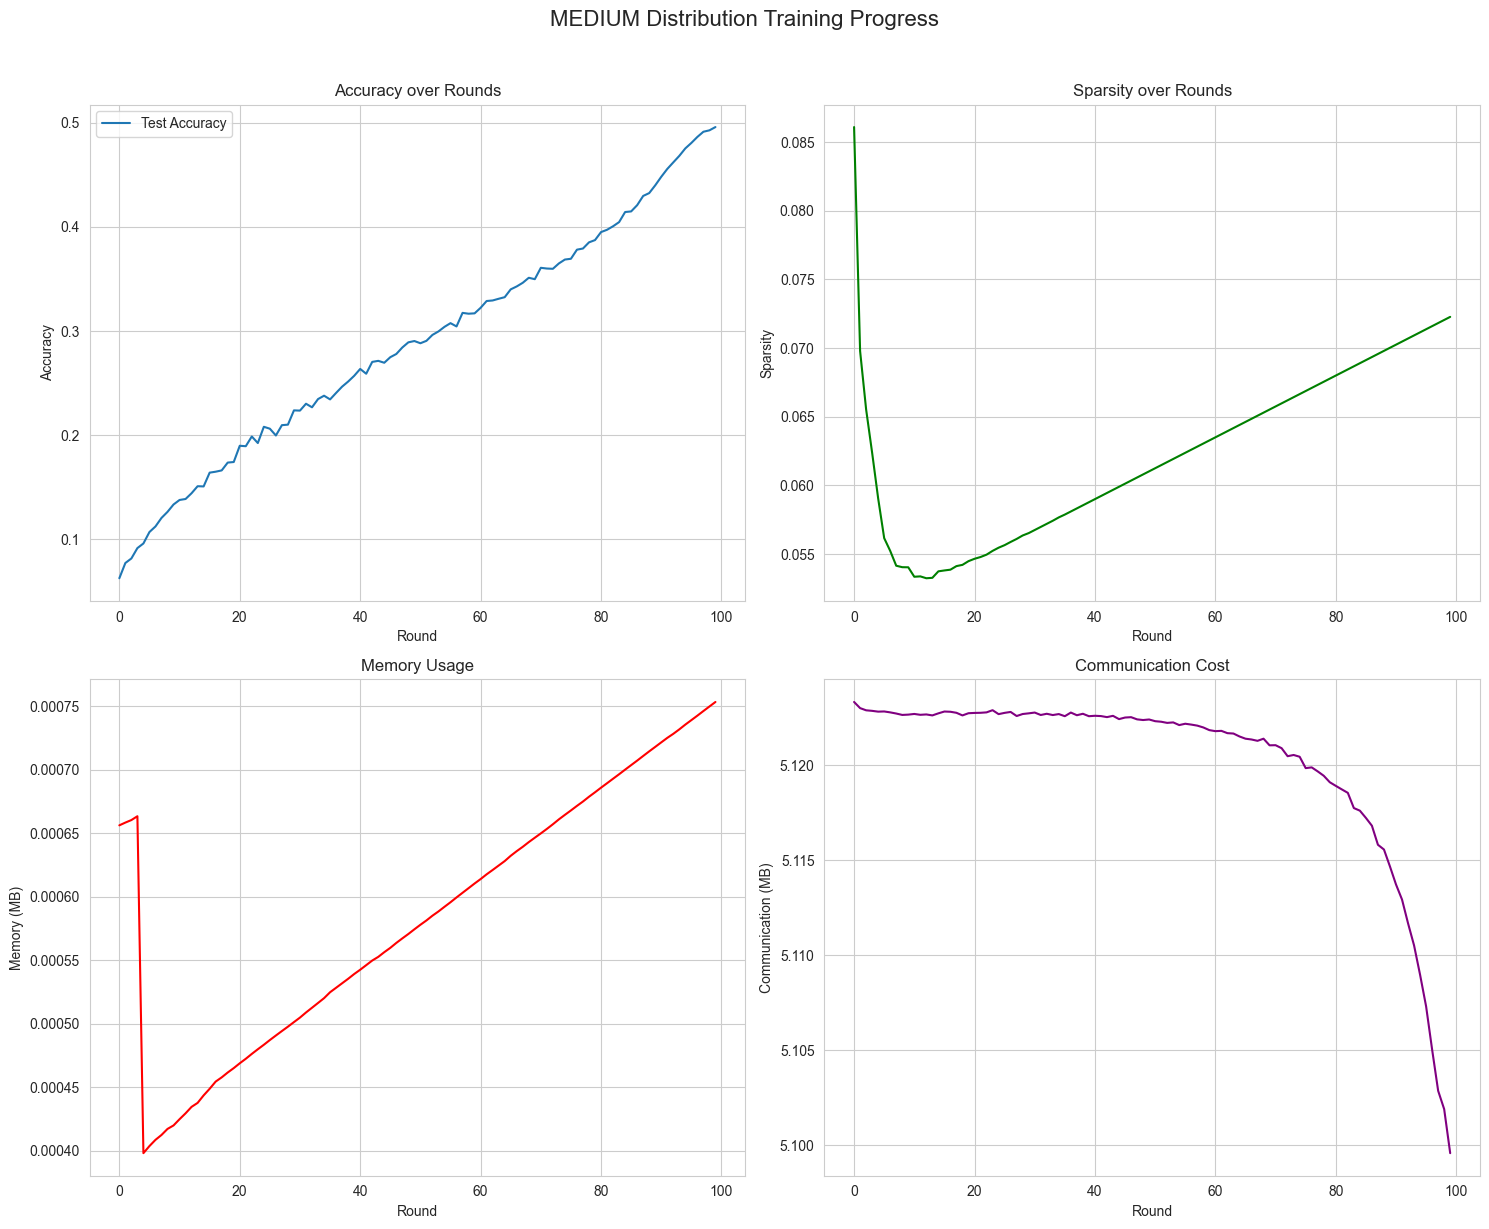

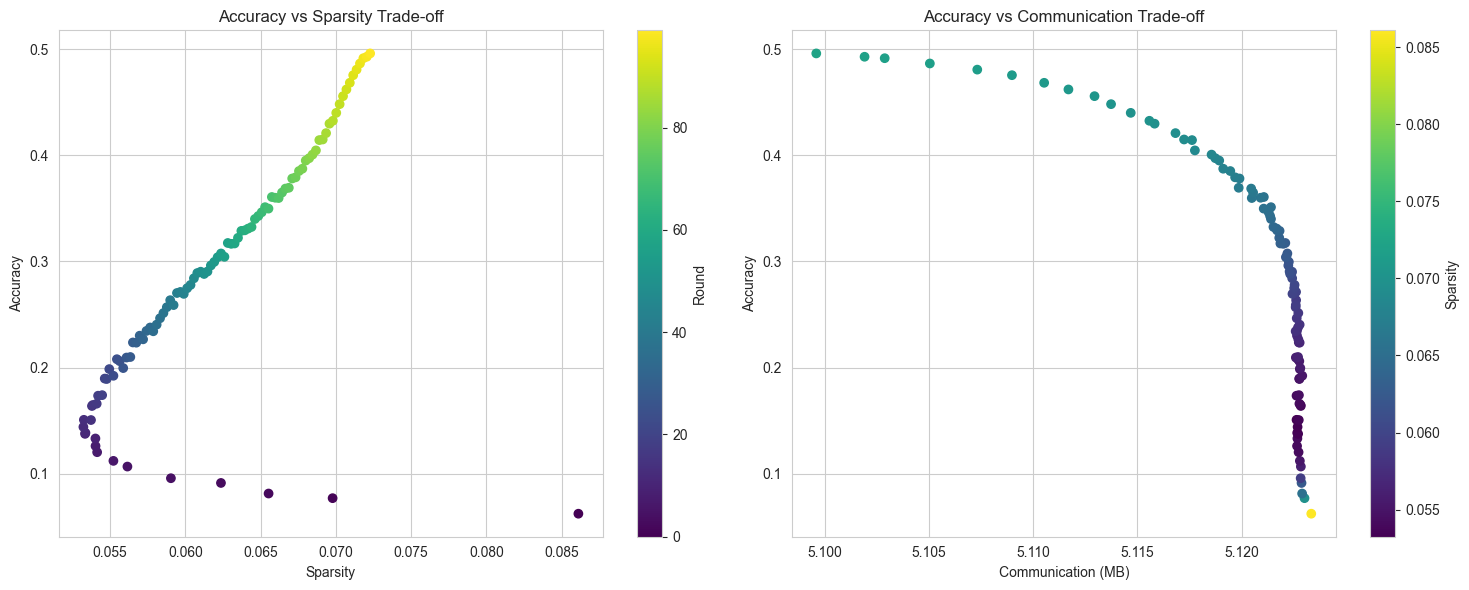

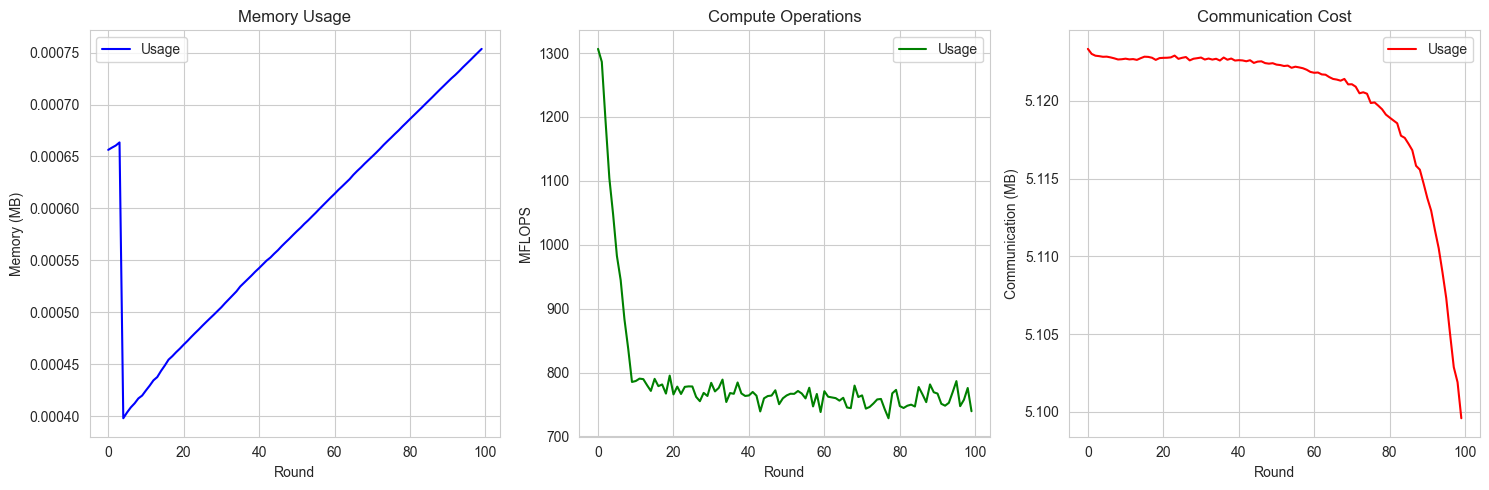

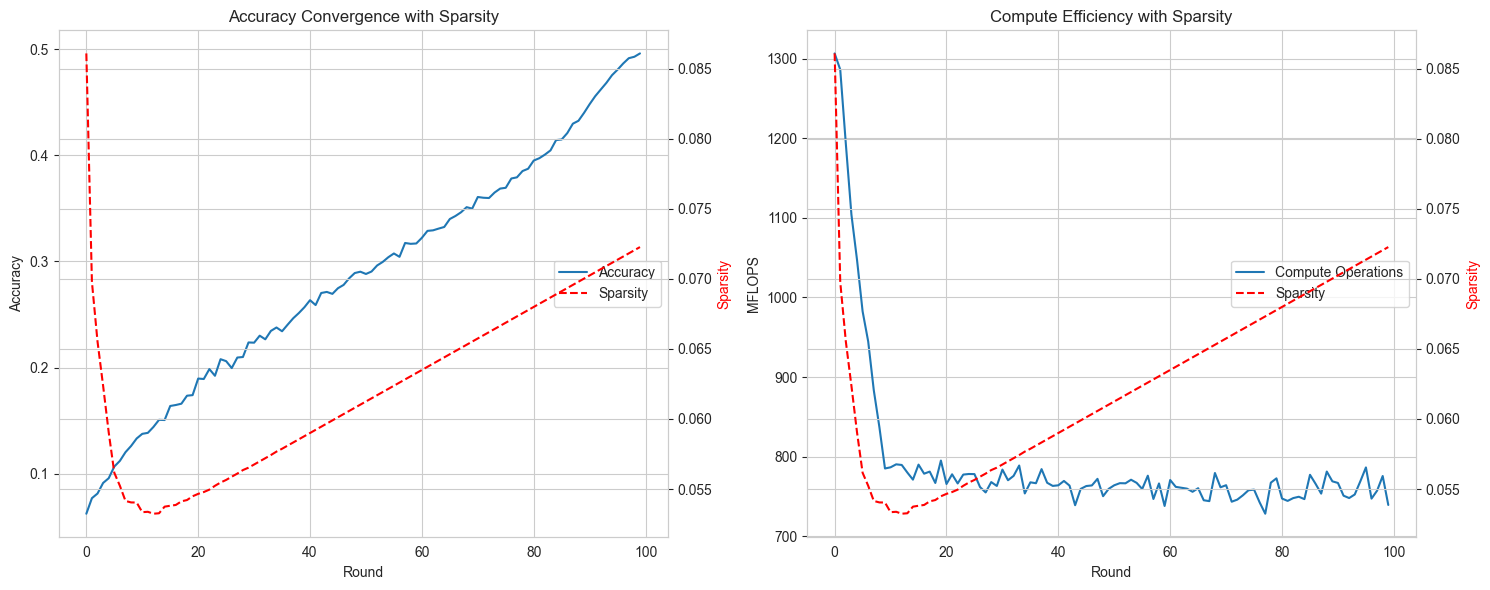


Summary Statistics:
         Final Accuracy  Max Accuracy  Average Memory (MB)  \
IID             0.51976       0.51986             0.000668   
NON-IID         0.28070       0.28526             0.000586   
MEDIUM          0.49604       0.49604             0.000585   

         Average Communication (MB)  Average FLOPS (MFLOPS)  Final Sparsity  \
IID                        5.117400              801.543169        0.072275   
NON-IID                    5.121407              794.657647        0.072275   
MEDIUM                     5.120199              791.557556        0.072275   

         Compression Ratio  Effective Compute Ratio  
IID               1.077906                 0.510236  
NON-IID           1.077906                 0.568665  
MEDIUM            1.077906                 0.525034  


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.visualization import (
    plot_training_metrics,
    plot_efficiency_metrics,
    plot_hardware_profile,
    plot_convergence_analysis
)


csv_paths = {
    'IID': 'results/cifaaaar100_dirichlet_iid_training_log.csv',
    'NON-IID': 'results/cifaaaar100_dirichlet_noniid_training_log.csv',
    'MEDIUM': 'results/cifaaaar100_dirichlet_medium_training_log.csv'
    
}

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        print(f"Found {partition} results at {path}")
    except FileNotFoundError:
        print(f"Warning: Could not find {partition} results at {path}")

for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        history = {
            'accuracy': df['accuracy'].values,
            'sparsity': df['sparsity'].values,
            'memory_bytes': df['memory_bytes'].values,
            'communication_bytes': df['communication_bytes'].values,
            'flops': df['flops'].values
        }
        plot_training_metrics(history, title_prefix=f"{partition} Distribution")
        plot_efficiency_metrics(history)
        plot_hardware_profile(history)
        plot_convergence_analysis(history)
    except Exception as e:
        print(f"Error plotting {partition} results: {e}")


summary_stats = {}
for partition, path in csv_paths.items():
    try:
        df = pd.read_csv(path)
        summary_stats[partition] = {
            'Final Accuracy': df['accuracy'].iloc[-1],
            'Max Accuracy': df['accuracy'].max(),
            'Average Memory (MB)': df['memory_bytes'].mean() / 1e6,
            'Average Communication (MB)': df['communication_bytes'].mean() / 1e6,
            'Average FLOPS (MFLOPS)': df['flops'].mean() / 1e6,
            'Final Sparsity': df['sparsity'].iloc[-1],
            'Compression Ratio': 1 / (1 - df['sparsity'].iloc[-1]),
            'Effective Compute Ratio': (1 - df['sparsity'].iloc[-1]) * df['flops'].iloc[-1] / df['flops'].iloc[0]
        }
    except Exception as e:
        print(f"Error calculating statistics for {partition}: {e}")

summary_df = pd.DataFrame(summary_stats).T
print("\nSummary Statistics:")
print(summary_df)